In [1]:
# install libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime
from pathlib import Path
from collections import defaultdict




In [23]:
# load AMI files

current_path = Path(os.getcwd())
ami_folder = current_path / '..'/ 'NREL'

ind_load_csv = ami_folder / 'consumption'/ 'ch1_4301002_individual.csv'
location_ref = ami_folder / 'location_reference.csv'
print('done')

done


In [24]:
# read csv and plot graphs

df = pd.read_csv(ind_load_csv)
df.head()

# Convert 'ENDTIME_EST' to datetime
df['ENDTIME_EST'] = pd.to_datetime(df['ENDTIME_EST'])
# Filter for dates from Jan 1 to Dec 31, 2024
df_2024 = df[(df['ENDTIME_EST'] >= '2024-01-01') & (df['ENDTIME_EST'] < '2025-01-01')]

print("Max INTERVAL_READ:", df_2024['INTERVAL_READ'].max())
# Max INTERVAL_READ: 48.96
print("Number of unique SERVICEPOINTID:", df_2024['SERVICEPOINTID'].nunique())


print(df_2024['INTERVAL_READ'].describe())
print("\nTop 10 highest INTERVAL_READ values:")
print(df_2024.sort_values('INTERVAL_READ', ascending=False).head(10))

# # Optional: remove any values over 5 (based on visual check / Excel)
# filtered_df = df_2024[df_2024['INTERVAL_READ'] <= 5]

# print(f"\nRemoved {len(df_2024) - len(filtered_df)} rows with INTERVAL_READ > 5 kWh")

print('done')


Max INTERVAL_READ: 48.96
Number of unique SERVICEPOINTID: 670
count    2.138023e+07
mean     3.236023e-01
std      1.164701e+00
min      0.000000e+00
25%      5.600000e-02
50%      1.310000e-01
75%      2.880000e-01
max      4.896000e+01
Name: INTERVAL_READ, dtype: float64

Top 10 highest INTERVAL_READ values:
          SERVICEPOINTID  CHANNELNUMBER         ENDTIME_EST  INTERVAL_READ
13119859      6000984488              1 2024-05-22 11:30:00          48.96
13119866      6000984488              1 2024-05-22 13:15:00          48.96
13119860      6000984488              1 2024-05-22 11:45:00          48.48
13119863      6000984488              1 2024-05-22 12:30:00          48.48
13119869      6000984488              1 2024-05-22 14:00:00          48.48
13119865      6000984488              1 2024-05-22 13:00:00          47.76
13119856      6000984488              1 2024-05-22 10:45:00          47.52
13119870      6000984488              1 2024-05-22 14:15:00          47.52
13119862     

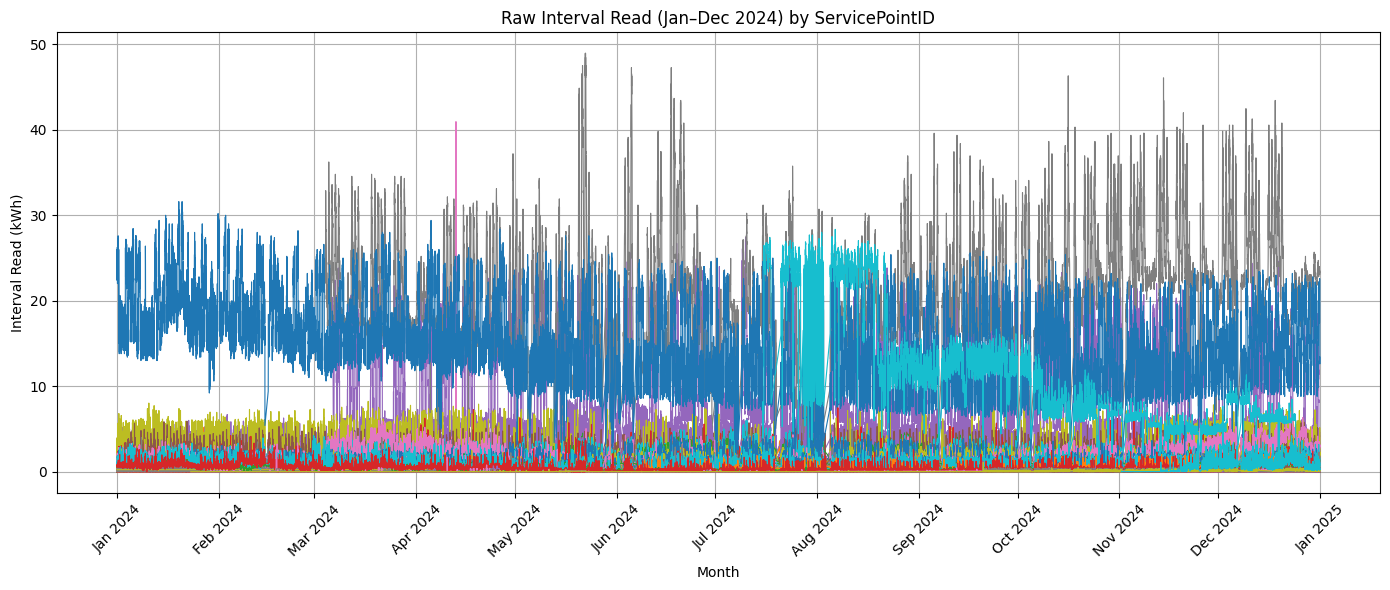

In [25]:
plt.figure(figsize=(14, 6))

for sp_id in df_2024['SERVICEPOINTID'].unique():
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
    plt.plot(sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'], label=f'SP {sp_id}', linewidth=0.8)

# Format x-axis to show month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels and layout
plt.xlabel('Month')
plt.ylabel('Interval Read (kWh)')
plt.title('Raw Interval Read (Jan–Dec 2024) by ServicePointID')
#plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small', ncol=1)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# read location reference


location_df = pd.read_csv(location_ref, dtype={'xfr_gisid': str, 'servicepointid': str})
location_df.head()

,servicepointid,circuit,xfr_gisid,amimeter,Residential,latitude,longitude
0,6000990168,4301002,220603575,Y,Res,42.491198,-76.299784
1,6000981995,4301002,220270492,Y,Res,42.494522,-76.304065
2,6000998944,4301002,220269834,Y,Res,42.491739,-76.273444
3,6000990452,4301002,220269968,Y,Res,42.497168,-76.279103
4,6000981895,4301002,220270495,Y,Res,42.494890,-76.305322


In [28]:
# service point id 

#node_id = ['220270493', '220270494', '220270496']

# Clean or standardize customer type column if needed
location_df['Residential'] = location_df['Residential'].str.strip()  # remove whitespace
location_df['Residential'] = location_df['Residential'].fillna('Unknown')  # handle NaNs

# Initialize nested defaultdict
nested_dict = defaultdict(lambda: defaultdict(list))

for _, row in location_df.iterrows():
    node_id = row['xfr_gisid']
    cust_type = row['Residential']
    servicepoint_id = row['servicepointid']
    nested_dict[node_id][cust_type].append(servicepoint_id)

# --- Step 3: Helper function to access servicepointids easily ---
def get_service_ids_by_type(load_id_dict, nested_dict, type_key='res'):
    """
    Given a load_id dictionary (e.g., {'res': '220603575'}),
    return list of servicepointids for that type (res or comm).
    """
    node_id = load_id_dict.get(type_key)
    if not node_id:
        return []
    # Capitalize 'res' → 'Res', 'comm' → 'Comm'
    cust_type = type_key.capitalize()
    return nested_dict.get(node_id, {}).get(cust_type, [])


print('done')

done


In [32]:
# LOAD ID 1


load_id = {'res': '220603575'}
service_ids = get_service_ids_by_type(load_id, nested_dict, 'res')
print(f"Residential servicepoint IDs for node {load_id['res']}: {service_ids}")

Residential servicepoint IDs for node 220603575: ['6000990168', '6000990209', '6000989830', '6000990138', '6000990146', '6000990084', '6000990155', '6000990185', '6000989893', '6000990224', '6000990256', '6003484559', '6000989910', '6000990236', '6000990294', '6000990191', '6000990262', '6000990162']


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/853190819.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/853190819.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_data['kW'] = sp_data['INTERVAL_READ'] * 4
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/853190819.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

<bound method NDFrame.head of          SERVICEPOINTID  CHANNELNUMBER         ENDTIME_EST  INTERVAL_READ
19127        6000973858              1 2024-01-01 00:00:00          0.095
19128        6000973858              1 2024-01-01 00:15:00          0.112
19129        6000973858              1 2024-01-01 00:30:00          0.118
19130        6000973858              1 2024-01-01 00:45:00          0.069
19131        6000973858              1 2024-01-01 01:00:00          0.081
...                 ...            ...                 ...            ...
39015656     6003668337              1 2024-12-31 22:45:00          0.185
39015657     6003668337              1 2024-12-31 23:00:00          0.730
39015658     6003668337              1 2024-12-31 23:15:00          0.928
39015659     6003668337              1 2024-12-31 23:30:00          0.368
39015660     6003668337              1 2024-12-31 23:45:00          0.236

[21380228 rows x 4 columns]>


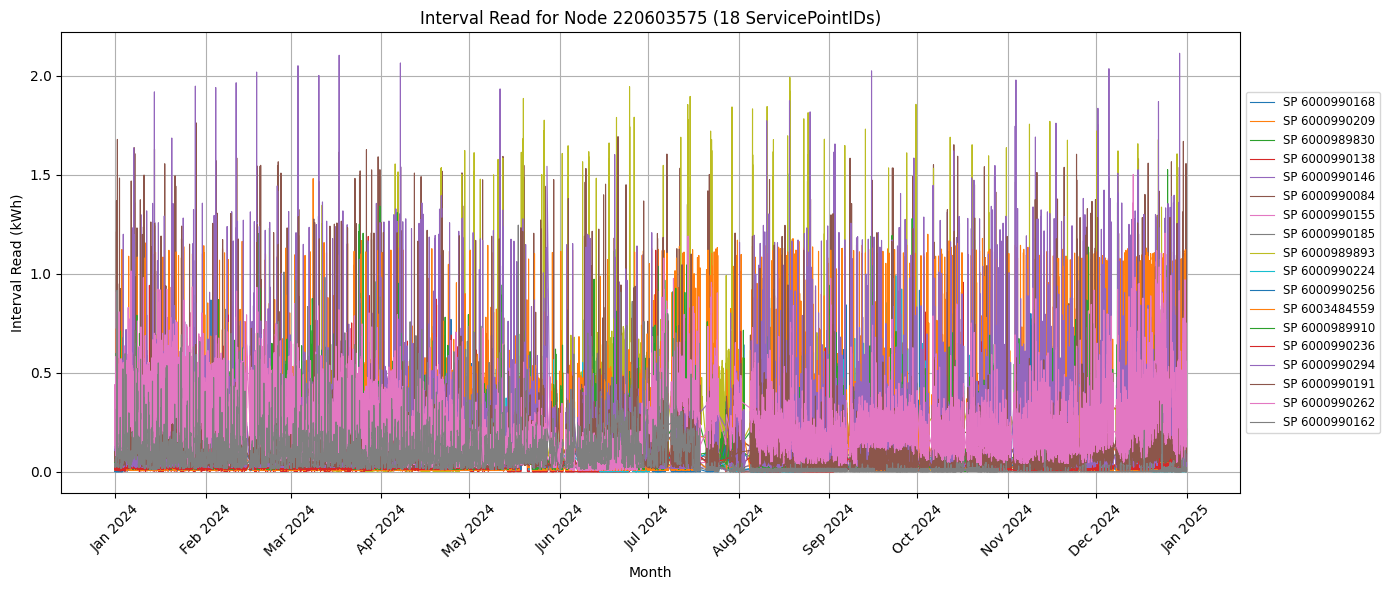

In [20]:
# LOAD ID 1

plt.figure(figsize=(14, 6))
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

for sp_id in service_ids:
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
    if not sp_data.empty:
        plt.plot(sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'], label=f'SP {sp_id}', linewidth=0.8)
print(df_2024.head)
# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kWh)')
plt.title(f'Interval Read for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/1575601154.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/1575601154.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_data['kW'] = sp_data['INTERVAL_READ'] * 4
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/1575601154.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

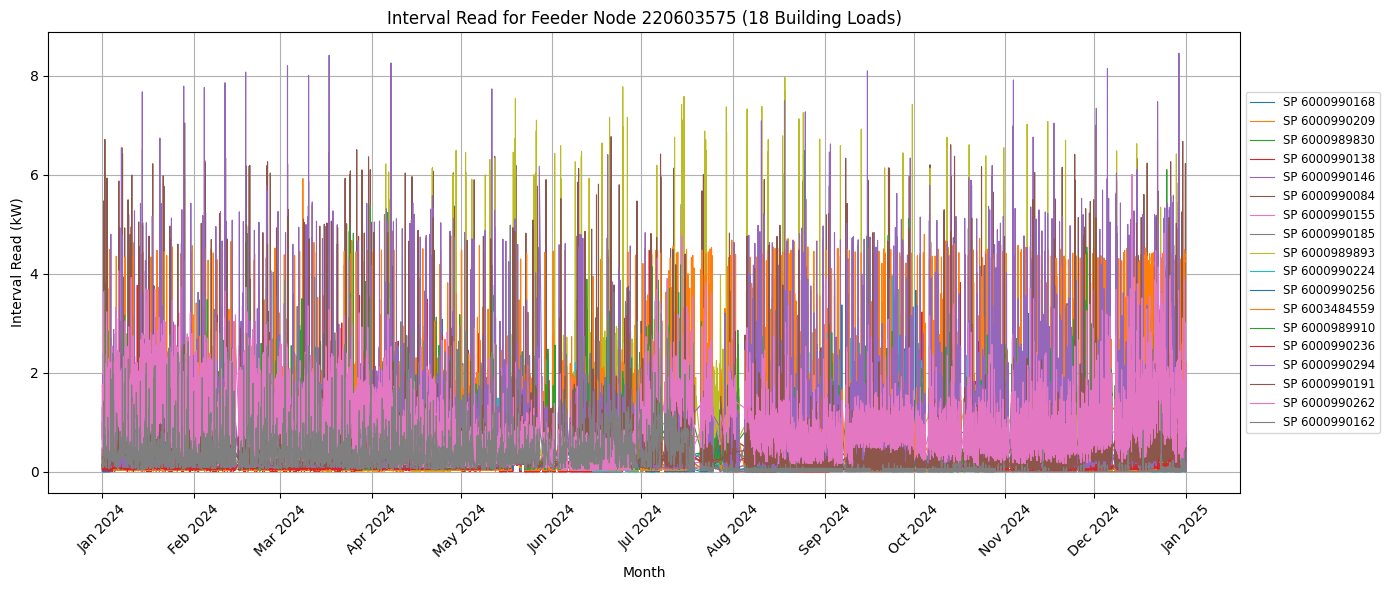

In [22]:
# LOAD ID 1

plt.figure(figsize=(14, 6))
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

for sp_id in service_ids:
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
    sp_data['kW'] = sp_data['INTERVAL_READ'] * 4
    if not sp_data.empty:
        plt.plot(sp_data['ENDTIME_EST'], sp_data['kW'], label=f'SP {sp_id}', linewidth=0.8)

# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Interval Read for Feeder Node {load_id["res"]} ({len(service_ids)} Building Loads)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/2697404429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)


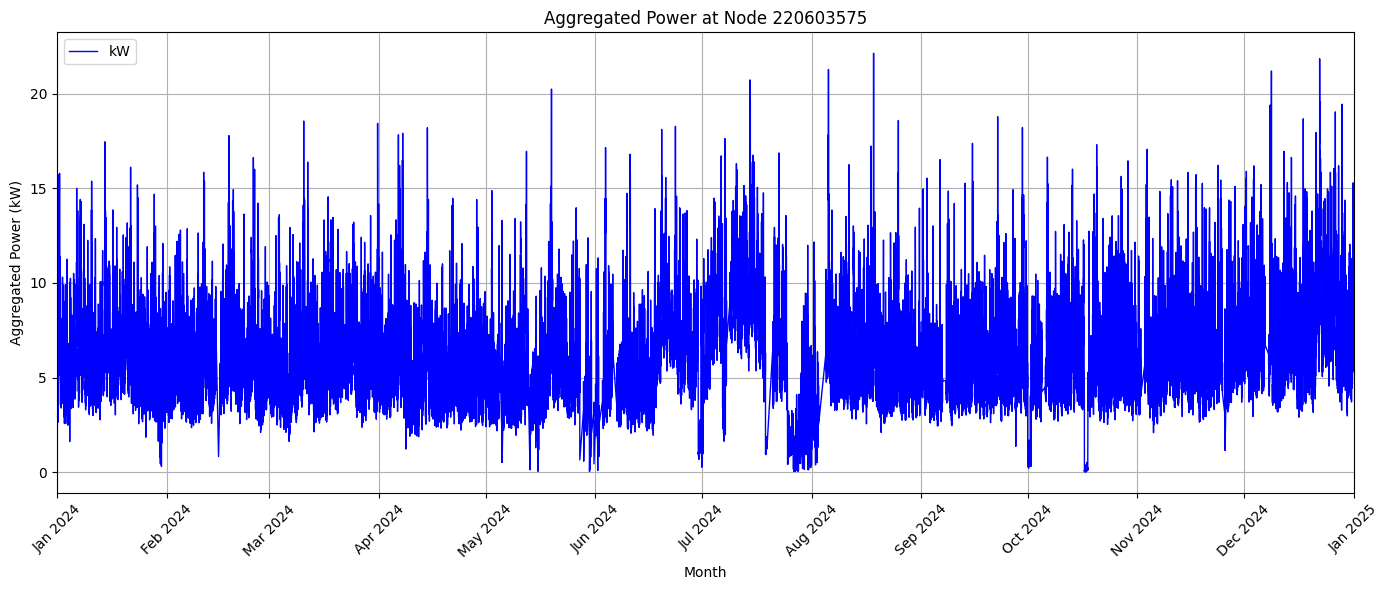

In [33]:
# LOAD ID 1

# Make sure SERVICEPOINTID is string
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024[df_2024['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kWh)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

# Convert 15-min kWh to kW
agg_df['kW'] = agg_df['INTERVAL_READ'] * 4

# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['kW'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))

# Labels
plt.xlabel('Month')
plt.ylabel('Aggregated Power (kW)')
plt.title(f'Aggregated Power at Node {load_id["res"]}')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [34]:
# LOAD ID 1

# Make sure SERVICEPOINTID is string
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024[df_2024['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kWh)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()



# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['kW'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))

# Labels
plt.xlabel('Month')
plt.ylabel('Aggregated Power (kW)')
plt.title(f'Aggregated Power at Node {load_id["res"]}')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/1714158245.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)


KeyError: 'kW'

<Figure size 1400x600 with 0 Axes>

In [30]:
# LOAD ID 2

load_id = {'res': '220270493'}
service_ids = get_service_ids_by_type(load_id, nested_dict, 'res')
print(f"Residential servicepoint IDs for node {load_id['res']}: {service_ids}")

Residential servicepoint IDs for node 220270493: ['6000982045', '6000982002', '6000981847', '6000981937', '6000981794', '6000981909', '6000981983', '6000981956', '6000981812', '6000982032', '6000981969']


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/528051728.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/528051728.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_data['kW'] = sp_data['INTERVAL_READ'] * 4
/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_5553/528051728.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

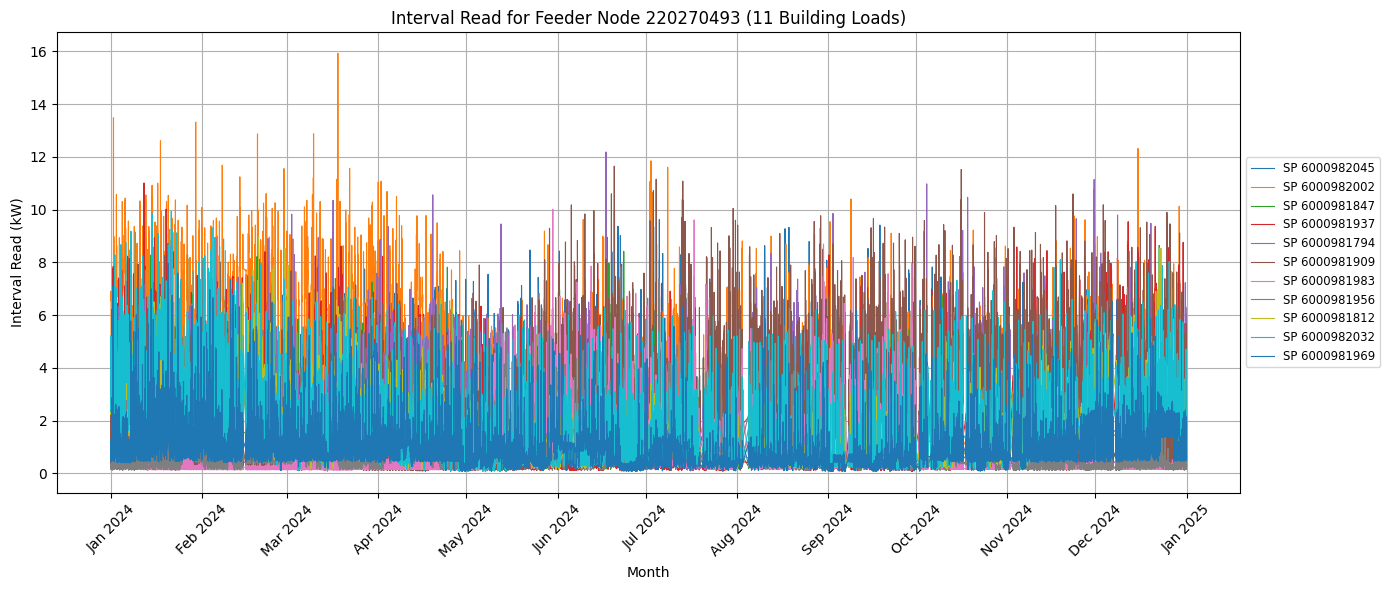

In [31]:
# LOAD ID 2

plt.figure(figsize=(14, 6))
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

for sp_id in service_ids:
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
    sp_data['kW'] = sp_data['INTERVAL_READ'] * 4
    if not sp_data.empty:
        plt.plot(sp_data['ENDTIME_EST'], sp_data['kW'], label=f'SP {sp_id}', linewidth=0.8)

# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Interval Read for Feeder Node {load_id["res"]} ({len(service_ids)} Building Loads)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# LOAD ID 3

# Make sure SERVICEPOINTID is string
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024[df_2024['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kWh)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

# Convert 15-min kWh to kW
agg_df['kW'] = agg_df['INTERVAL_READ'] * 4

# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['kW'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))

# Labels
plt.xlabel('Month')
plt.ylabel('Aggregated Power (kW)')
plt.title(f'Aggregated Power at Node {load_id["res"]}')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# LOAD ID 3